In [1]:
library(BiocManager)
library(regioneR)
library(GenomicRanges)
library(rtracklayer)
library(dplyr)
library(tidyr)
library(ggplot2)

Bioconductor version '3.18' is out-of-date; the current release version '3.23'
  is available with R version '4.6'; see https://bioconductor.org/install

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, sort, table, tap

In [2]:
peaks=read.csv('/nfs/team292/projects/PanTissue/data/temp/ATAC/processed/nonfetal_all/ArchRproj_subset/genefiles/peaks.csv')
linkedpeaks=read.csv('/nfs/team292/projects/PanTissue/data/temp/ATAC/processed/nonfetal_all/ArchRproj_subset/genefiles/peak2gene_links.csv')

In [3]:
encode=read.table('/nfs/team292/projects/PanTissue/data/freeze/ATAC/resources/GRCh38-cCREs.bed')
blacklist=read.table("/lustre/scratch125/cellgen/vento/cc53/utils/hg38-blacklist.v2.bed",sep='\t')

In [4]:
geneAnnotation=readRDS("/nfs/team292/projects/PanTissue/data/temp/GWASxRNA/RNA_references/10x_ref_geneAnnotation_hg38_2020A.rds")

In [5]:
peaks=peaks %>%
    separate(peak, into = c("chr", "start", "end"), sep = "[:-]") %>%
    mutate(start = as.integer(start), end = as.integer(end)) %>%
    select(chr, start, end)

In [6]:
linkedpeaks=linkedpeaks %>%
	#filter(Correlation>0.75) %>%
	filter(FDR<1e-5) %>%
	distinct(peakName) %>%
    separate(peakName, into = c("chr", "start", "end"), sep = "[:-]") %>%
    mutate(start = as.integer(start), end = as.integer(end)) %>%
    select(chr, start, end)

In [7]:
# convert dfs to GRanges
peaks_gr       <- toGRanges(peaks,       format="BED")
linkedpeaks_gr <- toGRanges(linkedpeaks, format="BED")
blacklist_gr   <- toGRanges(blacklist,   format="BED")

# build genome mask
genome_gr <- getGenomeAndMask(genome="hg38", mask=NULL)$genome
genome_gr <- subtractRegions(genome_gr, blacklist_gr)
gene_gr <- geneAnnotation$gene

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org


Attaching package: ‘Biostrings’


The following object is masked from ‘package:base’:

    strsplit


The masked version of 'hg38' is not installed. Using the unmasked version. This means that no automatic masking will be available.

Warning message in valid.GenomicRanges.seqinfo(x, suggest.trim = TRUE):
“GRanges object contains 16 out-of-bound ranges located on sequences chr10,
  chr11, chr12, chr14, chr15, chr17, chr18, chr19, chr1, chr20, chr21, chr3,
  chr4, chr5, chr7, and chrX. Note that ranges located on a sequence whose
  length is unknown (NA) or on a circular sequence are not considered
  out-of-bound (use seqlengths() and isCircular() to get the lengths and
  circularity flags of the underlying sequences). You can use trim() to trim
  these ranges. See ?`trim,GenomicRanges-method` f

In [8]:
hits_peaks      <- findOverlaps(peaks_gr,      gene_gr)
hits_linked     <- findOverlaps(linkedpeaks_gr, gene_gr)

peaks_intergenic_gr      <- peaks_gr[     -unique(queryHits(hits_peaks)), ]
linkedpeaks_intergenic_gr <- linkedpeaks_gr[-unique(queryHits(hits_linked)), ]

In [9]:
run_fisher <- function(all_gr, linked_gr, encode_gr) {
    in_encode <- countOverlaps(all_gr, encode_gr) > 0
    is_linked <- all_gr %over% linked_gr
    tab <- table(is_linked = is_linked, in_encode = in_encode)
    ft  <- fisher.test(tab)
    data.frame(
        OR        = ft$estimate,
        CI_low    = ft$conf.int[1],
        CI_high   = ft$conf.int[2],
        pval      = ft$p.value,
        n_linked  = sum(is_linked),
        n_unlinked = sum(!is_linked)
    )
}


In [10]:
results_list <- lapply(categories, function(cat) {
    encode_gr  <- toGRanges(encode[encode[[6]] == cat, ], format="BED")

    all_row  <- run_fisher(peaks_gr,             linkedpeaks_gr,             encode_gr)
    intr_row <- run_fisher(peaks_intergenic_gr,  linkedpeaks_intergenic_gr,  encode_gr)

    rbind(
        cbind(category = cat, peak_set = "All peaks",        all_row),
        cbind(category = cat, peak_set = "Intergenic peaks", intr_row)
    )
})

In [11]:
results_df <- do.call(rbind, results_list)
results_df$padj <- p.adjust(results_df$pval, method = "BH")

In [12]:
category_order <- c("PLS", "pELS", "dELS", "CA-TF", "CA-H3K4me3", "CA-CTCF", "TF", "CA")

results_df <- results_df |>
  mutate(category = factor(category, levels = rev(category_order)))

In [13]:
# ── forest plot ───────────────────────────────────────────────────────────────
pd <- position_dodge(width = 0.5)

p=ggplot(results_df, aes(x = OR, y = category, colour = peak_set, shape = peak_set)) +
    geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50") +
    geom_errorbarh(aes(xmin = CI_low, xmax = CI_high),
                   height = 0.15, position = pd) +
    geom_point(size = 1, position = pd) +
    geom_text(aes(label = ifelse(padj < 0.05, "*", ""), x = CI_high),
              hjust = -0.4, size = 5, position = pd, show.legend = FALSE) +
    scale_colour_manual(values = c("All peaks" = "#3a86ff", "Intergenic peaks" = "#ff006e")) +
    scale_shape_manual( values = c("All peaks" = 16,"Intergenic peaks" = 17)) +
    labs(
        x      = "Odds ratio (linked vs unlinked peaks)",
        y      = "ENCODE annotation category",
        colour = NULL,
        shape  = NULL
    ) +
    theme_classic() +
    theme(legend.position = "top")

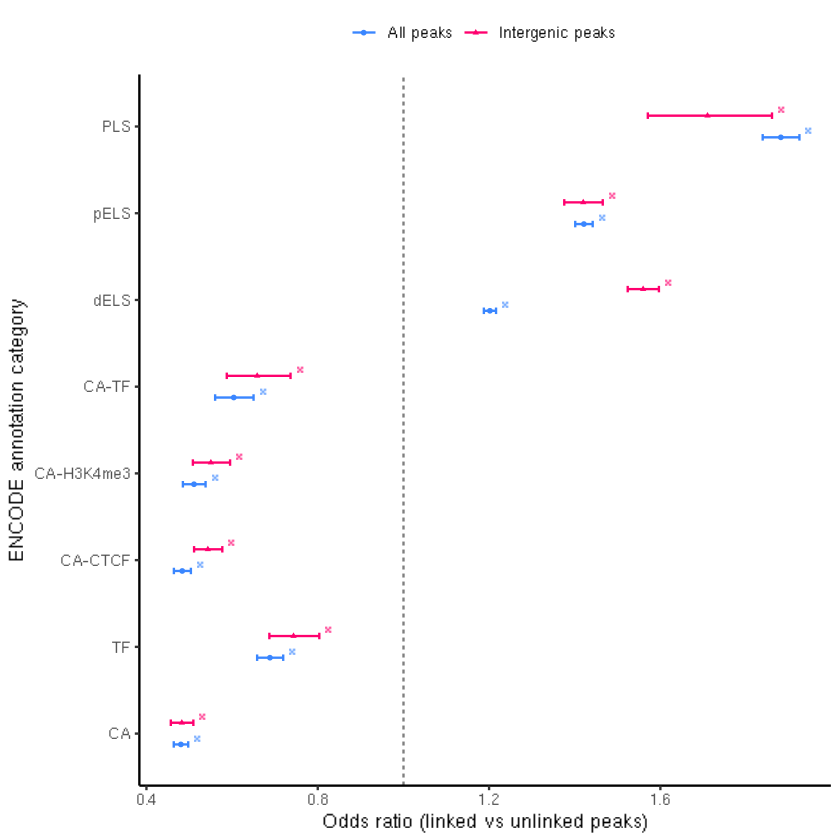

In [14]:
p

In [15]:
ggsave('/nfs/team292/projects/PanTissue/results/freeze/ATAC/plots/ENCODE_linked_vs_unlinked_OR.pdf',p,width=4,height=3)